In [1]:
## Preliminaries

using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using AdvancedHMC
using ArviZ
using BumpCosmologyGWTC3
using CairoMakie
using Colors
using Cosmology
using DataFrames
using DelimitedFiles
using DimensionalData
using Distributions
using GaussianKDEs
using HDF5
using InferenceObjects
using JSON
using KernelDensity
using LaTeXStrings
using MCMCChainsStorage
using NCDatasets
using PairPlots
using PolyLog
using PopModels
using Printf
using ProgressLogging
using Random
using StatsBase
using SpecialFunctions
using StatsFuns
using Trapz
using Turing
using Unitful
using UnitfulAstro
using UnitfulChainRules

include("plots.jl")

  Activating project at `~/high_mass_o4b/pop_model`


h_plot (generic function with 1 method)

# Load GWTC-5 Parameter Estimation Samples

In [2]:
## Samples and Selection

## Set up paths
struct Paths
    gwtc_2_dir::String
    gwtc_3_dir::String
    evt_table_file::String
    O4a_dir::String
    O4b_dir::String
end

paths = Paths(
    "/mnt/home/ccalvk/ceph/GWTC-2.1", 
    "/mnt/home/ccalvk/ceph/GWTC-3", 
    "/mnt/home/ccalvk/ceph/gwosc-snapshots/snapshot-2023-11-04/GWTC/GWTC.json",
    "/mnt/home/sroy1/ceph/O4/O4a_final_final_PE/bbh_only",
    "/mnt/home/sroy1/ceph/O4/O4b_final_final_PE"
)

## Output Directory for Plots and Astro Comparison Plot
outdir = "../figures/"

## Plot Specifications
xlabelsize = 28
ylabelsize = 28
xticklabelsize = 19
yticklabelsize = 19
titlesize = 35
draws = 500

plot_save = true

true

In [3]:
# O1 + O2 + O3
all_pe = load_pe(;
    gwtc_2_dir=paths.gwtc_2_dir,
    gwtc_3_dir=paths.gwtc_3_dir,
)

evt_table = load_event_table(paths.evt_table_file)
all_pe = join_pe_evt_tables(all_pe, evt_table)
all_pe = far_cut(all_pe)

# O4a
O4a_pe = load_pe_from_dir_O4(;
    dir=paths.O4a_dir,
    run=:O4a,
)

# O4b
O4b_pe = load_pe_from_dir_O4(;
    dir=paths.O4b_dir,
    run=:O4b,
)

# Compare O4a and O4b event names
o4a_names = Set(unique(O4a_pe.gwname))
o4b_names = Set(unique(O4b_pe.gwname))

@info "O4a unique events: $(length(o4a_names))"
@info "O4b unique events: $(length(o4b_names))"
@info "O4a ∩ O4b: $(length(intersect(o4a_names, o4b_names)))"
@info "O4b-only events: $(length(setdiff(o4b_names, o4a_names)))"

println("O4b-only names:")
println(sort(collect(setdiff(o4b_names, o4a_names))))

# Print event counts before combining
@info "O1/O2/O3 events: $(length(unique(all_pe.gwname)))"
@info "O4a events: $(length(unique(O4a_pe.gwname)))"
@info "O4b events: $(length(unique(O4b_pe.gwname)))"

# Combine O1/O2/O3 + O4a + O4b
all_pe = vcat(
    all_pe,
    O4a_pe,
    O4b_pe;
    cols=:intersect,
)

┌ Info: Could not read IGWN-GWTC2p1-v2-GW190425_081805_PEDataRelease_mixed_nocosmo.h5
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:26
┌ Info: Using C00:NRSur7dq4 for GW230601_224134
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:88
┌ Info: Using C00:Mixed for GW230605_065343
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:88
Loading IGWN HDF5 Files   2%|▋                           |  ETA: 0:00:48┌ Info: Using C00:NRSur7dq4 for GW230606_004305
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:88
┌ Info: Using C00:NRSur7dq4 for GW230608_205047
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:88
┌ Info: Using C00:NRSur7dq4 for GW230609_064958
└ @ BumpCosmologyGWTC3 /mnt/home/sroy1/high_mass_o4b/pop_model/src/load.jl:88
Loading IGWN HDF5 Files   6%|█▋                          |  ETA: 0:00:36┌ Info: Using C00:Mixed for GW230624_113103
└ @ BumpCosmologyGWTC3

O4b-only names:


┌ Info: O4b unique events: 103
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:28
┌ Info: O4a ∩ O4b: 0
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:29
┌ Info: O4b-only events: 103
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:30


SubString{String}["GW240413_022019", "GW240414_054515", "GW240420_175625", "GW240426_031451", "GW240428_225440", "GW240501_033534", "GW240505_133552", "GW240507_041632", "GW240511_031507", "GW240512_024139", "GW240513_183302", "GW240514_121713", "GW240515_005301", "GW240519_012815", "GW240520_213616", "GW240525_031210", "GW240526_093944", "GW240527_183429", "GW240527_230910", "GW240530_012417", "GW240531_040326", "GW240531_075248", "GW240601_061200", "GW240601_231004", "GW240612_081540", "GW240615_113620", "GW240615_160735", "GW240618_071627", "GW240621_195059", "GW240621_200935", "GW240621_214041", "GW240622_004008", "GW240627_131622", "GW240629_145256", "GW240630_101703", "GW240703_191355", "GW240705_053215", "GW240716_034900", "GW240824_205609", "GW240825_055146", "GW240830_211120", "GW240902_143306", "GW240907_153833", "GW240908_082628", "GW240908_125134", "GW240910_103535", "GW240915_001357", "GW240915_105151", "GW240916_184352", "GW240919_061559", "GW240920_073424", "GW240920_124

┌ Info: O1/O2/O3 events: 72
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:36
┌ Info: O4a events: 85
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:37
┌ Info: O4b events: 103
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W3sdnNjb2RlLXJlbW90ZQ==.jl:38


Row,spin_2y,dec,chirp_mass,redshift,theta_jn,ra,a_1,chi_p_2spin,viewing_angle,mass_1_source,cos_tilt_2,spin_2x,mass_2,cos_iota,chi_eff,mass_2_source,psi_J,log_likelihood,symmetric_mass_ratio,phi_12,spin_2z,phase,a_2,beta,spin_1z,chirp_mass_source,mass_ratio,comoving_distance,total_mass,mass_1,total_mass_source,chi_p,tilt_1,phi_1,tilt_2,cos_tilt_1,iota,luminosity_distance,phi_2,cos_theta_jn,inverted_mass_ratio,spin_1y,phi_jl,psi,spin_1x,gwname
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,SubStrin…
1,0.0157482,-1.2029,30.9684,0.0968552,2.77079,1.28323,0.00150978,0.0142601,0.370807,37.7342,0.827167,0.000942395,30.7108,-0.931191,0.00928814,27.999,2.70339,320.05,0.244516,2.46959,0.0232219,3.78693,0.028074,0.00264939,-0.0010508,28.2338,0.742006,418.022,72.0998,41.3889,65.7332,0.0112211,2.3406,5.32462,0.596749,-0.695997,2.76846,458.427,1.51103,-0.932035,1.3477,-0.000887186,2.07373,1.12909,0.000623018,GW150914_095045
2,0.306186,-1.17447,31.6976,0.0858721,2.58701,1.12687,0.927965,0.804829,0.554584,36.8689,-0.708659,-0.277814,33.1735,-0.876785,0.0308062,30.5501,3.19656,324.407,0.247804,0.924199,-0.415259,1.61676,0.585979,0.294629,0.400422,29.1909,0.828614,371.601,73.2084,40.0349,67.419,0.837126,1.12463,1.38345,2.35839,0.431506,2.63993,403.445,2.30765,-0.850119,1.20683,0.822478,5.85641,2.20776,0.155915,GW150914_095045
3,-0.281979,-1.20404,29.1559,0.0984072,2.65664,2.28386,0.377052,0.480531,0.48495,33.7307,0.069959,0.336426,30.3349,-0.864843,-0.164482,27.6172,1.85062,324.894,0.247517,5.15309,0.0307853,3.82701,0.440048,0.136484,-0.324358,26.5438,0.818754,424.561,67.3849,37.05,61.3479,0.349319,2.60655,0.43251,1.50078,-0.860247,2.61563,466.256,5.5856,-0.884698,1.22137,0.0805821,0.184376,0.549502,0.174548,GW150914_095045
4,-0.0257892,-1.28148,29.4337,0.0788087,2.46328,1.66579,0.436312,0.678088,0.678313,31.681,-0.548917,-0.578377,33.4479,-0.670639,-0.148147,31.0044,2.87312,325.099,0.249971,0.599913,-0.380195,0.994084,0.692628,0.250073,0.0789466,27.2835,0.978645,341.613,67.6256,34.1777,62.6854,0.564844,1.38885,2.58624,2.15186,0.180941,2.30587,368.478,3.18615,-0.778632,1.02182,0.226246,0.569816,1.58707,-0.364621,GW150914_095045
5,-0.615255,-1.22545,28.3426,0.093687,2.78603,2.18355,0.53497,0.32345,0.355559,35.457,-0.27069,-0.298152,27.4948,-0.906833,-0.213818,25.1395,4.77553,322.9,0.242752,2.08325,-0.192245,2.68165,0.710205,0.16795,-0.229113,25.9147,0.709015,404.658,66.2736,38.7788,60.5965,0.483425,2.01338,2.17789,1.84491,-0.428273,2.7065,442.491,4.26114,-0.937452,1.41041,0.397043,2.83741,2.81668,-0.275784,GW150914_095045
6,0.0101604,-1.2815,30.2896,0.105684,2.71688,1.89592,0.482283,0.45148,0.424714,33.7674,0.803428,-0.00136464,32.456,-0.945471,-0.0667451,29.3538,2.48545,323.721,0.248778,3.39295,0.0138334,4.20109,0.017218,0.134265,-0.136791,27.3944,0.869293,455.154,69.7921,37.3361,63.1212,0.462477,1.85838,4.59454,0.637765,-0.283633,2.80984,503.16,1.70431,-0.911157,1.15036,-0.459269,5.40313,1.17959,-0.0543767,GW150914_095045
7,-0.0143139,-1.22618,30.8565,0.120825,2.83255,2.33255,0.118997,0.0917852,0.309042,34.8008,0.970927,0.000399219,32.2669,-0.948892,-0.0101696,28.7885,3.17053,319.882,0.247765,4.02482,0.0580812,5.17008,0.0598203,0.0282465,-0.0666291,27.5301,0.827237,518.446,71.2725,39.0056,63.5893,0.0985938,2.16509,0.715448,0.241722,-0.559925,2.8205,580.964,4.74027,-0.952625,1.20884,0.0646731,2.74057,1.51725,0.0744185,GW150914_095045
8,-0.00522301,-1.25144,29.8868,0.118836,3.04766,2.17208,0.171419,0.835042,0.0939295,32.0239,-0.372615,0.805206,32.907,-0.983395,-0.122761,29.4119,0.71106,325.143,0.249548,0.138759,-0.323322,4.3655,0.867711,0.235285,0.0614407,26.7124,0.918436,510.159,68.7365,35.8294,61.4357,0.730616,1.20422,6.13794,1.95262,

In [4]:
groups_all_pe = groupby(all_pe, :gwname)

Row,spin_2y,dec,chirp_mass,redshift,theta_jn,ra,a_1,chi_p_2spin,viewing_angle,mass_1_source,cos_tilt_2,spin_2x,mass_2,cos_iota,chi_eff,mass_2_source,psi_J,log_likelihood,symmetric_mass_ratio,phi_12,spin_2z,phase,a_2,beta,spin_1z,chirp_mass_source,mass_ratio,comoving_distance,total_mass,mass_1,total_mass_source,chi_p,tilt_1,phi_1,tilt_2,cos_tilt_1,iota,luminosity_distance,phi_2,cos_theta_jn,inverted_mass_ratio,spin_1y,phi_jl,psi,spin_1x,gwname
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,SubStrin…
1,0.0157482,-1.2029,30.9684,0.0968552,2.77079,1.28323,0.00150978,0.0142601,0.370807,37.7342,0.827167,0.000942395,30.7108,-0.931191,0.00928814,27.999,2.70339,320.05,0.244516,2.46959,0.0232219,3.78693,0.028074,0.00264939,-0.0010508,28.2338,0.742006,418.022,72.0998,41.3889,65.7332,0.0112211,2.3406,5.32462,0.596749,-0.695997,2.76846,458.427,1.51103,-0.932035,1.3477,-0.000887186,2.07373,1.12909,0.000623018,GW150914_095045
2,0.306186,-1.17447,31.6976,0.0858721,2.58701,1.12687,0.927965,0.804829,0.554584,36.8689,-0.708659,-0.277814,33.1735,-0.876785,0.0308062,30.5501,3.19656,324.407,0.247804,0.924199,-0.415259,1.61676,0.585979,0.294629,0.400422,29.1909,0.828614,371.601,73.2084,40.0349,67.419,0.837126,1.12463,1.38345,2.35839,0.431506,2.63993,403.445,2.30765,-0.850119,1.20683,0.822478,5.85641,2.20776,0.155915,GW150914_095045
3,-0.281979,-1.20404,29.1559,0.0984072,2.65664,2.28386,0.377052,0.480531,0.48495,33.7307,0.069959,0.336426,30.3349,-0.864843,-0.164482,27.6172,1.85062,324.894,0.247517,5.15309,0.0307853,3.82701,0.440048,0.136484,-0.324358,26.5438,0.818754,424.561,67.3849,37.05,61.3479,0.349319,2.60655,0.43251,1.50078,-0.860247,2.61563,466.256,5.5856,-0.884698,1.22137,0.0805821,0.184376,0.549502,0.174548,GW150914_095045
4,-0.0257892,-1.28148,29.4337,0.0788087,2.46328,1.66579,0.436312,0.678088,0.678313,31.681,-0.548917,-0.578377,33.4479,-0.670639,-0.148147,31.0044,2.87312,325.099,0.249971,0.599913,-0.380195,0.994084,0.692628,0.250073,0.0789466,27.2835,0.978645,341.613,67.6256,34.1777,62.6854,0.564844,1.38885,2.58624,2.15186,0.180941,2.30587,368.478,3.18615,-0.778632,1.02182,0.226246,0.569816,1.58707,-0.364621,GW150914_095045
5,-0.615255,-1.22545,28.3426,0.093687,2.78603,2.18355,0.53497,0.32345,0.355559,35.457,-0.27069,-0.298152,27.4948,-0.906833,-0.213818,25.1395,4.77553,322.9,0.242752,2.08325,-0.192245,2.68165,0.710205,0.16795,-0.229113,25.9147,0.709015,404.658,66.2736,38.7788,60.5965,0.483425,2.01338,2.17789,1.84491,-0.428273,2.7065,442.491,4.26114,-0.937452,1.41041,0.397043,2.83741,2.81668,-0.275784,GW150914_095045
6,0.0101604,-1.2815,30.2896,0.105684,2.71688,1.89592,0.482283,0.45148,0.424714,33.7674,0.803428,-0.00136464,32.456,-0.945471,-0.0667451,29.3538,2.48545,323.721,0.248778,3.39295,0.0138334,4.20109,0.017218,0.134265,-0.136791,27.3944,0.869293,455.154,69.7921,37.3361,63.1212,0.462477,1.85838,4.59454,0.637765,-0.283633,2.80984,503.16,1.70431,-0.911157,1.15036,-0.459269,5.40313,1.17959,-0.0543767,GW150914_095045
7,-0.0143139,-1.22618,30.8565,0.120825,2.83255,2.33255,0.118997,0.0917852,0.309042,34.8008,0.970927,0.000399219,32.2669,-0.948892,-0.0101696,28.7885,3.17053,319.882,0.247765,4.02482,0.0580812,5.17008,0.0598203,0.0282465,-0.0666291,27.5301,0.827237,518.446,71.2725,39.0056,63.5893,0.0985938,2.16509,0.715448,0.241722,-0.559925,2.8205,580.964,4.74027,-0.952625,1.20884,0.0646731,2.74057,1.51725,0.0744185,GW150914_095045
8,-0.00522301,-1.25144,29.8868,0.118836,3.04766,2.17208,0.171419,0.835042,0.0939295,32.0239,-0.372615,0.805206,32.907,-0.983395,-0.122761,29.4119,0.71106,325.143,0.249548,0.138759,-0.323322,4.3655,0.867711,0.235285,0.0614407,26.7124,0.918436,510.159,68.7365,35.8294,61.4357,0.730616,1.20422,6.13794,1.95262,

In [5]:
pe = mass_cut(all_pe, thresh=0.5)
groups = groupby(pe, :gwname)

Row,spin_2y,dec,chirp_mass,redshift,theta_jn,ra,a_1,chi_p_2spin,viewing_angle,mass_1_source,cos_tilt_2,spin_2x,mass_2,cos_iota,chi_eff,mass_2_source,psi_J,log_likelihood,symmetric_mass_ratio,phi_12,spin_2z,phase,a_2,beta,spin_1z,chirp_mass_source,mass_ratio,comoving_distance,total_mass,mass_1,total_mass_source,chi_p,tilt_1,phi_1,tilt_2,cos_tilt_1,iota,luminosity_distance,phi_2,cos_theta_jn,inverted_mass_ratio,spin_1y,phi_jl,psi,spin_1x,gwname
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,SubStrin…
1,-0.361884,-0.454484,42.6978,0.34624,2.26706,4.93797,0.103945,0.34581,0.874534,54.0953,0.216273,-0.0483144,33.9831,-0.605213,0.0876596,25.2429,2.5159,49.0137,0.216937,1.60404,0.0808742,1.16425,0.373945,0.0517145,0.0908259,31.7164,0.466638,1402.47,106.808,72.8253,79.3382,0.15354,0.50786,2.97563,1.3528,0.873787,2.22083,1887.34,4.57967,-0.641354,2.14299,0.00835091,2.04499,0.915452,-0.0498549,GW170729_185629
2,0.429181,-1.02713,41.585,0.378877,2.39425,5.44432,0.226822,0.812392,0.747341,50.591,-0.474999,-0.563788,33.5773,-0.635545,-0.00543917,24.3512,2.64048,49.1407,0.219351,6.01335,-0.382465,1.53051,0.805191,0.164082,0.176036,30.1586,0.481334,1521.43,103.336,69.7588,74.9422,0.308559,0.682341,2.76076,2.06576,0.776098,2.25951,2097.04,2.49093,-0.733499,2.07756,0.0531652,0.916594,1.19879,-0.132789,GW170729_185629
3,0.21843,-1.24588,52.4074,0.490753,0.322369,5.75694,0.606857,0.286354,0.322369,49.7346,0.315441,-0.702198,49.2866,0.900796,0.359535,33.0615,2.94616,52.3902,0.239862,4.17765,0.244452,3.50304,0.774952,0.131769,0.436038,35.155,0.664759,1912.32,123.429,74.142,82.7961,0.461514,0.769127,4.94555,1.24987,0.718518,0.449196,2849.61,2.84001,0.948487,1.50431,-0.410653,4.38907,1.27908,0.0975223,GW170729_185629
4,-0.246884,-0.827363,53.7504,0.557889,0.897795,5.27817,0.850588,0.371402,0.897795,48.2798,-0.771508,0.13587,51.0634,0.524103,0.337037,32.7773,3.92845,47.9079,0.240855,5.94667,-0.341726,2.89333,0.442932,0.139173,0.797851,34.5021,0.678903,2134.66,126.278,75.2146,81.0571,0.294844,0.353982,5.55201,2.452,0.938,1.01913,3324.18,5.21549,0.623336,1.47297,-0.196881,5.24942,2.44108,0.219478,GW170729_185629
5,0.571079,-1.00337,46.4262,0.404833,2.32303,5.56831,0.640768,0.595299,0.818561,56.2295,0.0665277,0.142286,37.0278,-0.468697,0.205944,26.3575,4.59594,44.8349,0.217293,5.50086,0.039241,3.32303,0.589844,0.33182,0.284086,33.0475,0.468748,1614.43,116.021,78.993,82.5869,0.57435,1.11146,2.10894,1.50422,0.443353,2.05861,2267.1,1.32661,-0.683272,2.13334,0.493173,2.30044,2.77677,-0.294378,GW170729_185629
6,-0.109811,-1.20446,53.0382,0.337366,1.26225,5.66588,0.503433,0.162719,1.26225,61.2832,-0.386603,-0.102857,46.0386,0.235986,0.288109,34.4248,3.29396,52.2505,0.230312,5.49487,-0.0630723,3.20538,0.163145,0.0706672,0.485379,39.6587,0.561733,1369.73,127.997,81.9581,95.7081,0.133613,0.268623,4.748,1.96774,0.964137,1.33256,1831.14,3.95968,0.303672,1.7802,-0.133528,4.61096,1.71581,0.00475661,GW170729_185629
7,0.0507226,-0.21326,44.3086,0.175377,1.75826,4.75797,0.134807,0.0651156,1.38333,60.4755,-0.612689,-0.0156933,37.2031,-0.157165,0.0667323,31.6521,4.32484,44.1651,0.225529,0.755459,-0.0411611,2.98524,0.067181,0.0331058,0.123202,37.6974,0.523386,742.425,108.285,71.0815,92.1276,0.054718,0.417963,1.11539,2.23025,0.913918,1.72862,872.39,1.87085,-0.186366,1.91064,0.0491413,1.10799,2.76901,0.0240665,GW170729_185629
8,-0.148282,-0.946543,49.4801,0.368082,2.2175,5.31692,0.282569,0.160404,0.924093,63.0017,0.313984,0.17902,38.6721,-0.669028,0.199877,28.2674,2.95949,46.5651,0.213792,0.170117,0.0768752,2.7397,0.244838,0.0914683,0.255064,36.1675,0.448676,1482.33,124.864,86.1915,91.2691,0.121603,0.44488,5.42131,1.25141,0.902662,2.3037,2027.16,5.59143,-0.602558,2.

In [6]:
gw_names = [group.gwname[1] for group in groups]

open("../data/analyzed_gw_event_names.txt", "w") do io
    for name in gw_names
        println(io, name)
    end
end

println(gw_names)
println(length(gw_names))

SubString{String}["GW170729_185629", "GW190413_134308", "GW190519_153544", "GW190521_030229", "GW190602_175927", "GW190620_030421", "GW190701_203306", "GW190706_222641", "GW190929_012149", "GW191109_010717", "GW191127_050227", "GW191230_180458", "GW200216_220804", "GW230601_224134", "GW230608_205047", "GW230630_125806", "GW230704_212616", "GW230707_124047", "GW230708_230935", "GW230806_204041", "GW230814_061920", "GW230819_171910", "GW230820_212515", "GW230824_033047", "GW230914_111401", "GW230922_040658", "GW230928_215827", "GW231001_140220", "GW231004_232346", "GW231005_021030", "GW231008_142521", "GW231028_153006", "GW231029_111508", "GW231102_071736", "GW231119_075248", "GW231123_135430", "GW231127_165300", "GW231221_135041", "GW231223_032836", "GW231230_170116", "GW240107_013215", "GW240426_031451", "GW240514_121713", "GW240519_012815", "GW240527_183429", "GW240601_061200", "GW240612_081540", "GW240618_071627", "GW240705_053215", "GW240824_205609", "GW240923_204006", "GW241114_024

# Plot PE Samples
## $m_1-m_2$ Plane

┌ Info: Number of events plotted: 61
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sdnNjb2RlLXJlbW90ZQ==.jl:16


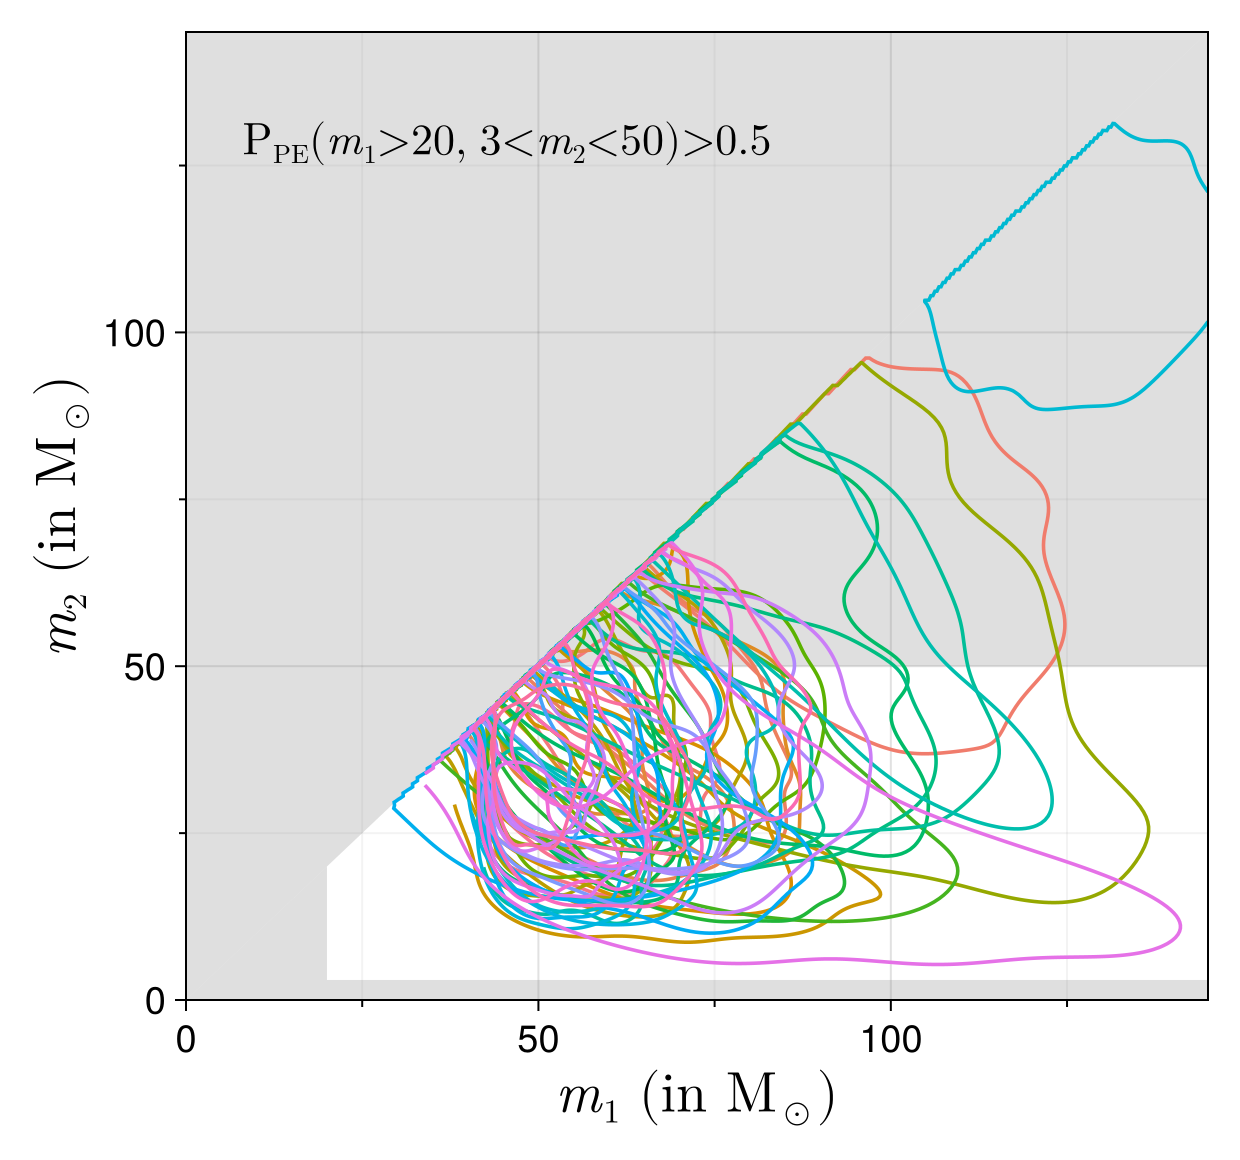

In [8]:
function m1m2_kde_plot(df;
    include_legend = false,
    rng = Random.default_rng(),
    level = 0.1,
    draw_cut_lines = true,
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    mlow = 0.0,
    mhigh = 145.0
)

    # df should already contain only events passing the mass cut
    evt_groups = DataFrames.groupby(df, :gwname)

    @info "Number of events plotted: $(length(evt_groups))"

    cs = categorical_palette(length(evt_groups))

    f = Figure(size = (620, 580))

    a = Axis(f[1, 1];
        xlabel = L"m_1~\mathrm{(in~}\mathrm{M}_\odot)",
        ylabel = L"m_2~\mathrm{(in~}\mathrm{M}_\odot)",
        limits = (mlow, mhigh, mlow, mhigh),
        xminorgridvisible = true,
        xminorticksvisible = true,
        yminorgridvisible = true,
        yminorticksvisible = true,
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize
    )

    # Shade regions outside the mass range
    if draw_cut_lines
        poly!(
            a,
            [0.0, m1_min, m1_min],
            [0.0, 0.0, m1_min],
            color = (:grey, 0.25)
        )

        poly!(
            a,
            [m1_min, m1_min, mhigh, mhigh],
            [0.0, m2_min, m2_min, 0.0],
            color = (:grey, 0.25)
        )

        poly!(
            a,
            [m2_max, mhigh, mhigh],
            [m2_max, mhigh, m2_max],
            color = (:grey, 0.25)
        )
    end

    # Shade unphysical m2 > m1 region
    band!(
        a,
        [mlow, mhigh],
        [mlow, mhigh],
        [mhigh, mhigh],
        color = (:grey, 0.25)
    )

    text!(
        a,
        8.0,
        132.0;
        text = L"\mathrm{P}_{\mathrm{PE}}(m_1>20,\;3<m_2<50)>0.5",
        align = (:left, :top),
        fontsize = 22,
        color = :black
    )

    @progress for (i, evt) in enumerate(evt_groups)

        npe = size(evt, 1)
        ndraw = min(256, npe)

        draw_inds = randperm(rng, npe)[1:ndraw]
        evt_draw = evt[draw_inds, :]

        x = evt_draw[!, :mass_1_source]
        y = evt_draw[!, :mass_2_source]

        kde_pts = vcat(x', y')
        k = KDE(kde_pts)

        # Symmetrized KDE density at posterior samples
        p_kde_pts = [
            pdf(k, [kde_pts[1, j], kde_pts[2, j]]) +
            pdf(k, [kde_pts[2, j], kde_pts[1, j]])
            for j in axes(kde_pts, 2)
        ]

        plev = quantile(p_kde_pts, level)

        dx = maximum(x) - minimum(x)
        dy = maximum(y) - minimum(y)

        xgrid = range(
            max(mlow, minimum(x) - 0.1dx),
            min(mhigh, maximum(x) + 0.1dx),
            length = 160
        )

        ygrid = range(
            max(mlow, minimum(y) - 0.1dy),
            min(mhigh, maximum(y) + 0.1dy),
            length = 160
        )

        zgrid = [
            xv ≥ yv ?
            pdf(k, [xv, yv]) + pdf(k, [yv, xv]) :
            zero(xv)
            for xv in xgrid, yv in ygrid
        ]

        contour!(
            a,
            xgrid,
            ygrid,
            zgrid;
            levels = [plev],
            color = cs[i],
            linewidth = 1.8,
            label = include_legend ? evt[1, :gwname] : nothing
        )
    end

    if include_legend
        axislegend(
            a,
            position = :lt,
            labelsize = xticklabelsize,
            framevisible = true
        )
    end

    return f
end


# pe already contains only events satisfying:
# P_PE(m1 > 20, 3 < m2 < 50) > 0.5
f = m1m2_kde_plot(
    pe;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    draw_cut_lines = true,
    mhigh = 145.0
)

if plot_save
    resize_to_layout!(f)
    save(outdir * "m1_m2_kde_mass_cut.pdf", f, px_per_unit = 3)
end

f

┌ Info: Number of events plotted: 61
└ @ Main /mnt/home/sroy1/high_mass_o4b/pop_model/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sdnNjb2RlLXJlbW90ZQ==.jl:12


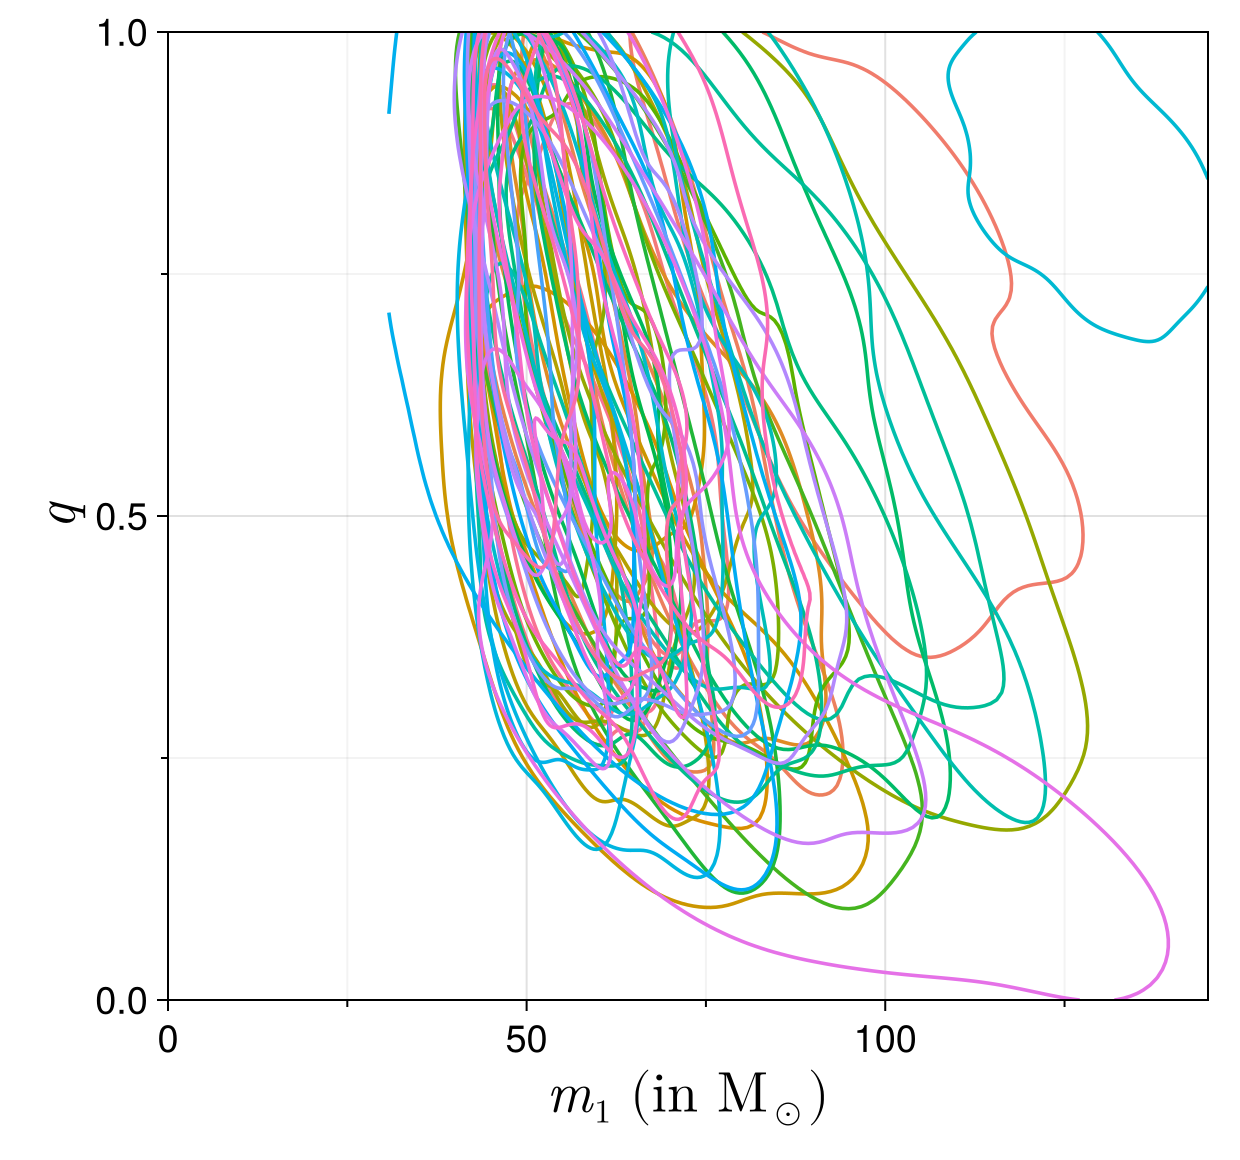

In [9]:
function m1q_kde_plot(df;
    include_legend = false,
    rng = Random.default_rng(),
    level = 0.1,
    mlow = 0.0,
    mhigh = 145.0
)

    # df should already contain only events that pass the mass cut
    evt_groups = DataFrames.groupby(df, :gwname)

    @info "Number of events plotted: $(length(evt_groups))"

    cs = categorical_palette(length(evt_groups))

    f = Figure(size = (620, 580))

    a = Axis(f[1, 1];
        xlabel = L"m_1~\mathrm{(in~}\mathrm{M}_\odot)",
        ylabel = L"q",
        limits = (mlow, mhigh, 0.0, 1.0),
        xminorgridvisible = true,
        xminorticksvisible = true,
        yminorgridvisible = true,
        yminorticksvisible = true,
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize
    )

    @progress for (i, evt) in enumerate(evt_groups)
        c = cs[i]

        npe = size(evt, 1)
        ndraw = min(256, npe)
        draw_inds = randperm(rng, npe)[1:ndraw]

        evt_draw = evt[draw_inds, :]

        x = evt_draw[!, :mass_1_source]
        y = evt_draw[!, :mass_2_source] ./ evt_draw[!, :mass_1_source]

        kde_pts = vcat(x', y')
        k = KDE(kde_pts)

        p_kde_pts = [pdf(k, [kde_pts[1, j], kde_pts[2, j]]) for j in axes(kde_pts, 2)]
        plev = quantile(p_kde_pts, level)

        dx = maximum(x) - minimum(x)
        xgrid = range(
            max(mlow, minimum(x) - 0.1 * dx),
            min(mhigh, maximum(x) + 0.1 * dx),
            length = 128
        )

        dy = maximum(y) - minimum(y)
        ylo = max(0.0, minimum(y) - 0.1 * dy)
        yhi = min(1.0, maximum(y) + 0.1 * dy)
        ygrid = range(ylo, yhi, length = 129)

        zgrid = [pdf(k, [xv, yv]) for xv in xgrid, yv in ygrid]

        label = include_legend ? evt[1, :gwname] : nothing
        contour!(a, xgrid, ygrid, zgrid;
            levels = [plev],
            color = c,
            linewidth = 1.8,
            label = label
        )
    end

    if include_legend
        axislegend(
            a,
            position = :rt,
            labelsize = xlabelsize,
            framevisible = true
        )
    end

    return f
end

f = m1q_kde_plot(pe)

if plot_save
    resize_to_layout!(f)
    save(outdir * "m1_q_kde.pdf", f, px_per_unit = 3)
end

f

┌ Info: Training samples for KDE: 11500
└ @ Main /mnt/home/sroy1/35_GWTC4_Mod/GWTC4_35_m1m2z_Feb23/Events/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sdnNjb2RlLXJlbW90ZQ==.jl:60
┌ Info: Resample bandwidths: hMc=1.475741858916766, hq=0.032487257083522805
└ @ Main /mnt/home/sroy1/35_GWTC4_Mod/GWTC4_35_m1m2z_Feb23/Events/scripts/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sdnNjb2RlLXJlbW90ZQ==.jl:64


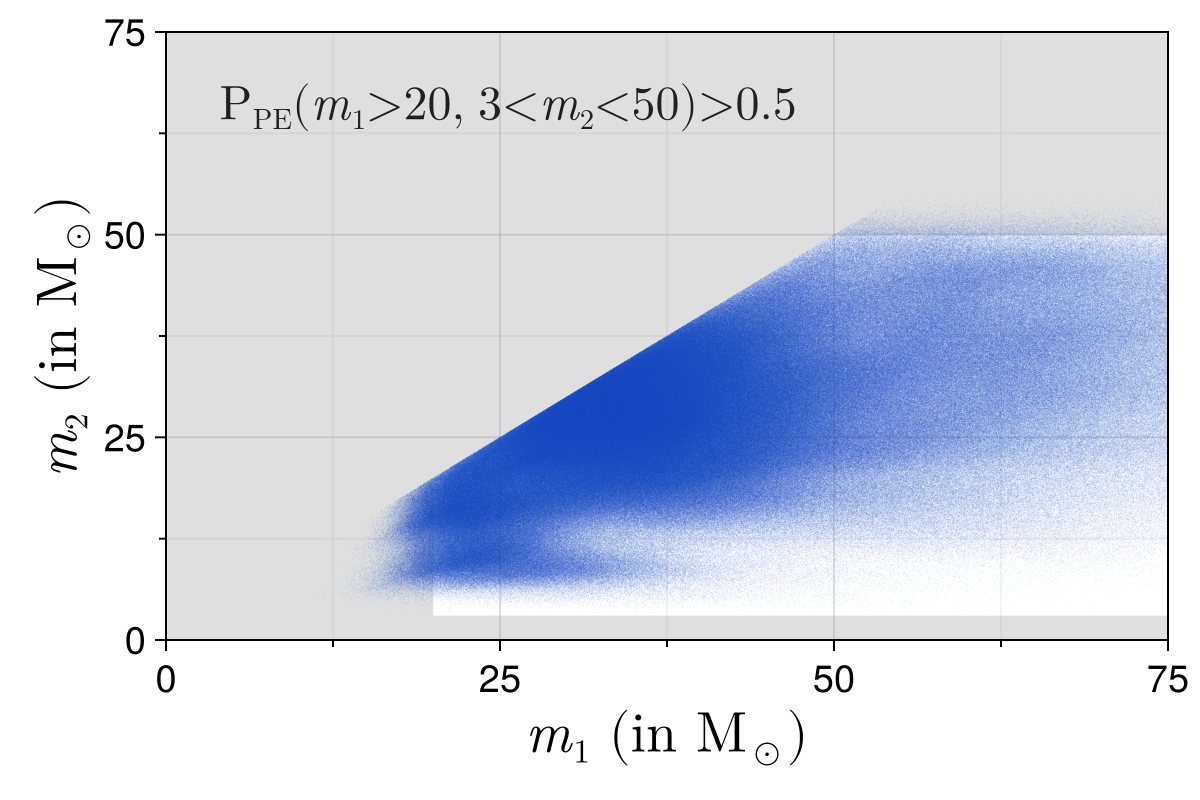

In [15]:
chirp_mass(m1, m2) = (m1*m2)^0.6 / (m1 + m2)^0.2

function mcq_to_m1m2(Mc, q)
    m1 = Mc * (1 + q)^(1/5) / (q^(3/5))
    m2 = q * m1
    return m1, m2
end

function silverman_bw(x::AbstractVector)
    n = length(x)
    s = std(x)
    return 1.06 * s * n^(-1/5)
end

function m1m2_scatter_from_mcq_kde(df;
    nsamp_per_event::Int = 100,
    n_resample::Int = 5_000_000,
    rng=Random.default_rng(),
    q_eps::Float64 = 1e-4,
    marker_size=0.6,
    alpha=0.10,

    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    draw_cut_lines::Bool = true,
    p_text = 0.5,

    m_max_plot::Float64 = 75.0
)
    evt_groups = DataFrames.groupby(df, :gwname)

    Mc_all = Float64[]
    q_all  = Float64[]

    for evt in evt_groups
        m1 = evt[!, :mass_1_source]
        m2 = evt[!, :mass_2_source]
        npe = length(m1)
        npe == 0 && continue

        inds = rand(rng, 1:npe, nsamp_per_event)
        for j in inds
            m1j = float(m1[j])
            m2j = float(m2[j])

            if m2j > m1j
                m1j, m2j = m2j, m1j
            end

            qj = clamp(m2j / m1j, q_eps, 1 - q_eps)
            Mcj = chirp_mass(m1j, m2j)

            (isfinite(Mcj) && Mcj > 0) || continue
            push!(Mc_all, Mcj)
            push!(q_all, qj)
        end
    end

    @info "Training samples for KDE: $(length(Mc_all))"

    hMc = silverman_bw(Mc_all)
    hq  = silverman_bw(q_all)
    @info "Resample bandwidths: hMc=$(hMc), hq=$(hq)"

    Ntrain = length(Mc_all)

    m1_s = Float64[]
    m2_s = Float64[]
    sizehint!(m1_s, n_resample)
    sizehint!(m2_s, n_resample)

    while length(m1_s) < n_resample
        i = rand(rng, 1:Ntrain)
        Mc = Mc_all[i] + rand(rng, Normal(0, hMc))
        q  = q_all[i]  + rand(rng, Normal(0, hq))

        if !(isfinite(Mc) && isfinite(q))
            continue
        end
        if Mc <= 0
            continue
        end
        if q <= 0 || q >= 1
            continue
        end

        m1, m2 = mcq_to_m1m2(Mc, q)

        if !(isfinite(m1) && isfinite(m2))
            continue
        end

        if m2 > m1
            m1, m2 = m2, m1
        end

        if m1 > m_max_plot || m2 > m_max_plot
            continue
        end

        push!(m1_s, m1)
        push!(m2_s, m2)
    end

    mlow  = 0.0
    mhigh = m_max_plot

    f = Figure(size=(600, 400))
    a = Axis(f[1, 1];
        xlabel=L"m_1~\mathrm{(in~}\mathrm{M}_\odot)",
        ylabel=L"m_2~\mathrm{(in~}\mathrm{M}_\odot)",
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        limits=(mlow, mhigh, mlow, mhigh),
        xminorgridvisible=true, xminorticksvisible=true,
        yminorgridvisible=true, yminorticksvisible=true
    )

    if draw_cut_lines
        poly!(a, [0.0, m1_min, m1_min], [0.0, 0.0, m1_min], color=(:grey, 0.25))
        poly!(a, [m1_min, m1_min, mhigh, mhigh], [0.0, m2_min, m2_min, 0.0], color=(:grey, 0.25))
        poly!(a, [m2_max, mhigh, mhigh], [m2_max, mhigh, m2_max], color=(:grey, 0.25))

        cut_label = latexstring(
            "{\\mathrm{P}}_{\\mathrm{PE}}(" *
            "m_1 > " * string(Int(round(m1_min))) * ",\\;" *
            string(Int(round(m2_min))) * " < m_2 < " * string(Int(round(m2_max))) *
            ") > " * string(p_text)
        )

        text!(
            a,
            4.0, mhigh - 6.0;
            text = cut_label,
            align = (:left, :top),
            fontsize = 24,
            color = :black
        )
    end

    band!(a, [mlow, mhigh], [mlow, mhigh], [mhigh, mhigh], color=(:grey, 0.25))

    scatter!(a, m1_s, m2_s;
        markersize = marker_size,
        color = (RGBf(0.1, 0.3, 0.75), alpha),
        rasterize = 4
    )

    return f, (m1=m1_s, m2=m2_s, Mc_train=Mc_all, q_train=q_all, bw=(hMc, hq))
end

f, out = m1m2_scatter_from_mcq_kde(
    pe;
    nsamp_per_event = 100,
    n_resample      = 5_000_000,
    m_max_plot      = 75.0,
    marker_size     = 0.6,
    alpha           = 0.10,
    draw_cut_lines  = true,
    p_text          = 0.5,
    m1_min          = 20.0,
    m2_min          = 3.0,
    m2_max          = 50.0
)

#if plot_save
#    resize_to_layout!(f)
#    save(outdir * "m1_m2_kde_resample.pdf", f, px_per_unit = 3)
#end

f

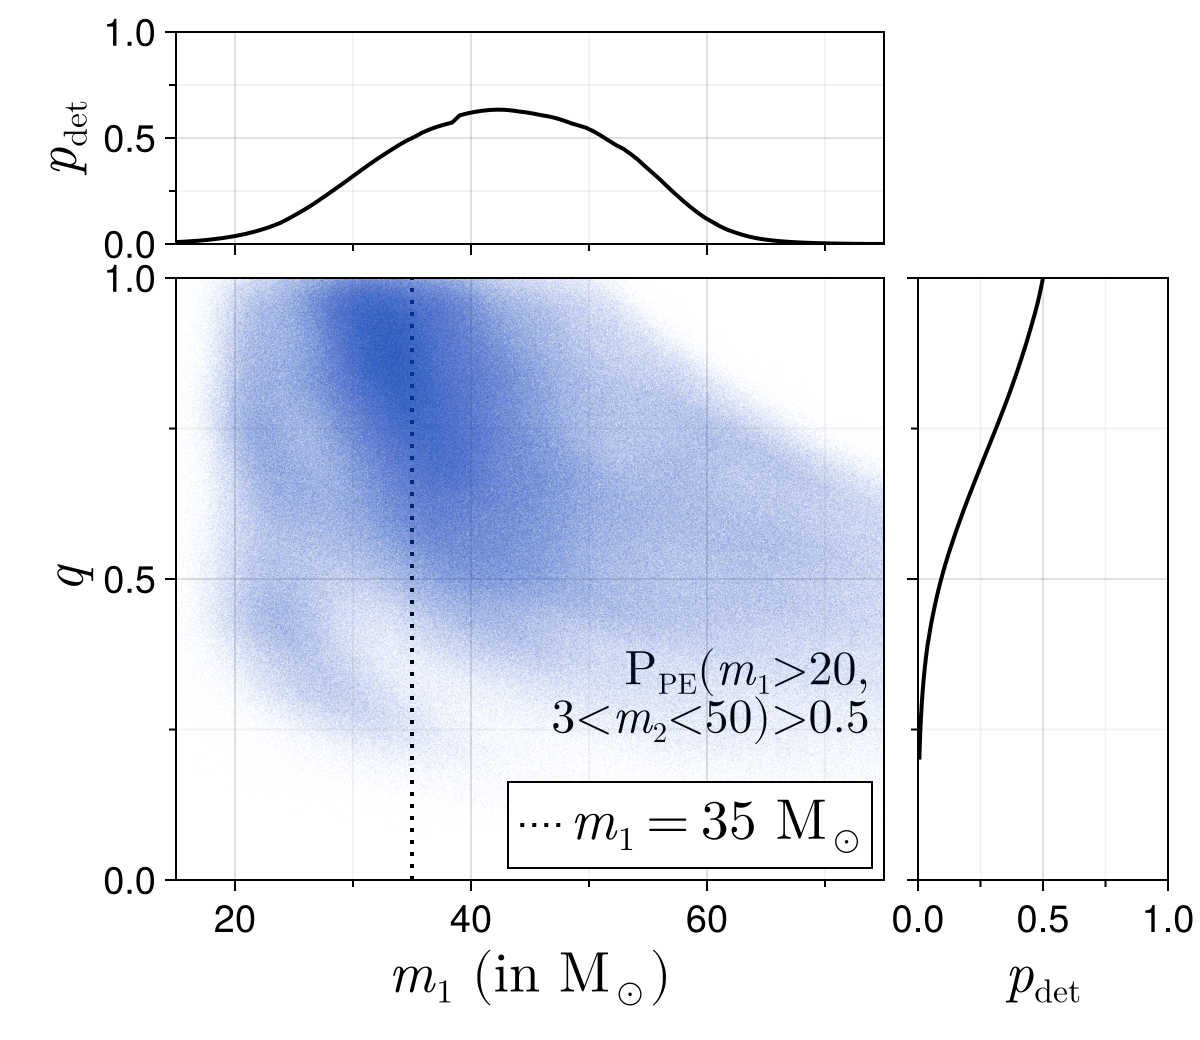

In [16]:
function m1q_scatter_from_kde_samples(out;
    marker_size=0.6,
    alpha=0.05,
    m_max_plot::Float64=75.0,
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    pdet_m1_file = "../data/m1_q1_z0p5_pdet.txt",
    pdet_q_file = "../data/q_m1_35_z0p5_pdet.txt"
)
    qs = Float64[]
    m1s = Float64[]
    sizehint!(qs, min(length(out.m1), length(out.m2)))
    sizehint!(m1s, min(length(out.m1), length(out.m2)))

    for (m1, m2) in zip(out.m1, out.m2)
        if isfinite(m1) && isfinite(m2) && m1 > 0 && m2 > 0
            if m2 > m1
                m1, m2 = m2, m1
            end
            q = m2 / m1
            if isfinite(q) && 0 < q < 1 && m1 <= m_max_plot
                push!(m1s, m1)
                push!(qs, q)
            end
        end
    end

    pdet_m1 = readdlm(pdet_m1_file)
    pdet_q = readdlm(pdet_q_file)

    f = Figure(size=(600, 520))

    at = Axis(f[1, 1];
        ylabel = L"p_{\mathrm{det}}",
        limits = (15.0, m_max_plot, 0.0, 1.0),
        xticklabelsvisible = false,
        xminorgridvisible = true, xminorticksvisible = true,
        yminorgridvisible = true, yminorticksvisible = true,
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize
    )

    a = Axis(f[2, 1];
        xlabel=L"m_1~\mathrm{(in~}\mathrm{M}_\odot)",
        ylabel=L"q",
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        limits=(15.0, m_max_plot, 0.0, 1.0),
        xminorgridvisible=true, xminorticksvisible=true,
        yminorgridvisible=true, yminorticksvisible=true
    )

    ar = Axis(f[2, 2];
        xlabel = L"p_{\mathrm{det}}",
        limits = (0.0, 1.0, 0.0, 1.0),
        yticklabelsvisible = false,
        xminorgridvisible = true, xminorticksvisible = true,
        yminorgridvisible = true, yminorticksvisible = true,
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize
    )

    rowsize!(f.layout, 1, Relative(0.26))
    rowsize!(f.layout, 2, Relative(0.74))
    colsize!(f.layout, 1, Relative(0.74))
    colsize!(f.layout, 2, Relative(0.26))
    rowgap!(f.layout, 12)
    colgap!(f.layout, 12)

    lines!(at, pdet_m1[:, 1], pdet_m1[:, 2], color = :black, linewidth = 2.0)
    lines!(ar, pdet_q[:, 2], pdet_q[:, 1], color = :black, linewidth = 2.0)

    cut_label_1 = L"\mathrm{P}_{\mathrm{PE}}(m_1 > 20,"
    cut_label_2 = L"3 < m_2 < 50) > 0.5"

    text!(
        a,
        0.98, 0.30;   # moved up
        text = cut_label_1,
        align = (:right, :bottom),
        fontsize = 24,
        color = :black,
        space = :relative
    )

    text!(
        a,
        0.98, 0.22;   # moved up
        text = cut_label_2,
        align = (:right, :bottom),
        fontsize = 24,
        color = :black,
        space = :relative
    )

    lines!(a, [35.0, 35.0], [0.0, 1.0],
        color = :black,
        linestyle = :dot,
        linewidth = 2,
        label = L"m_1 = 35~\mathrm{M}_\odot"
    )

    scatter!(a, m1s, qs;
        markersize = marker_size,
        color = (RGBf(0.1, 0.3, 0.75), alpha),
        rasterize = 4
    )

    axislegend(a,
        position = :rb,
        labelsize = xlabelsize,
        framevisible = true
    )

    linkxaxes!(at, a)
    linkyaxes!(a, ar)

    return f
end

f_m1q = m1q_scatter_from_kde_samples(
    out;
    marker_size = 0.6,
    alpha = 0.05,
    m_max_plot = 75.0
)

#if plot_save
#    resize_to_layout!(f_m1q)
#    save(outdir * "m1_q_kde_resample.pdf", f_m1q, px_per_unit = 3)
#end

f_m1q

# Redshift

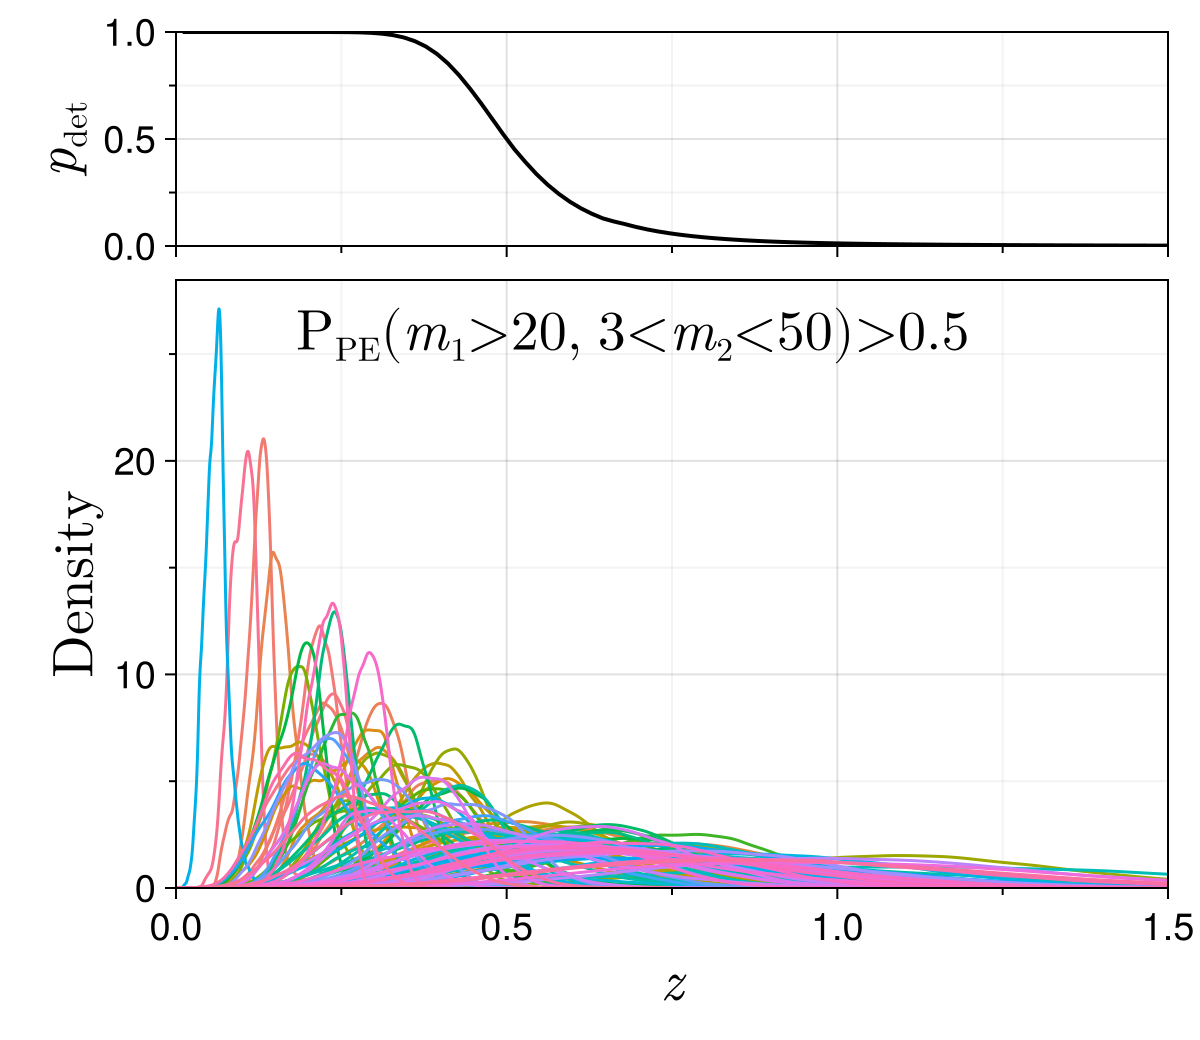

In [17]:
function frac_mass_bounds(df, m1_min, m2_min, m2_max)
    m1s = df[!, :mass_1_source]
    m2s = df[!, :mass_2_source]
    p_in = sum((m1s .> m1_min) .& (m2s .> m2_min) .& (m2s .< m2_max)) / length(m1s)
    p_in
end

function z_kde_plot(df;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    include_legend = false,
    p_cut = 0.5,
    pdet_z_file = "../data/z_m1_35_q1_pdet.txt"
)
    evt_groups = DataFrames.groupby(df, :gwname)

    evt_groups = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    cs = categorical_palette(length(evt_groups))

    zlow = 0.0
    zhigh = 1.5

    pdet_z = readdlm(pdet_z_file)

    f = Figure(size = (600, 520))

    at = Axis(f[1, 1];
        ylabel = L"p_{\mathrm{det}}",
        limits = (zlow, zhigh, 0.0, 1.0),
        xticklabelsvisible = false,
        xminorgridvisible = true, xminorticksvisible = true,
        yminorgridvisible = true, yminorticksvisible = true,
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize
    )

    a = Axis(f[2, 1];
        xlabel = L"z",
        ylabel = L"\mathrm{Density}",
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        limits = (zlow, zhigh, nothing, nothing),
        xminorgridvisible = true, xminorticksvisible = true,
        yminorgridvisible = true, yminorticksvisible = true
    )

    rowsize!(f.layout, 1, Relative(0.26))
    rowsize!(f.layout, 2, Relative(0.74))
    rowgap!(f.layout, 12)

    lines!(at, pdet_z[:, 1], pdet_z[:, 2], color = :black, linewidth = 2.0)

    # 🔥 FIX: use L"" instead of latexstring → correct font size
    cut_label = L"\mathrm{P}_{\mathrm{PE}}(m_1 > 20,\; 3 < m_2 < 50) > 0.5"

    ymax = 0.0

    @progress for (i, evt) in enumerate(evt_groups)
        c = cs[i]

        z = evt[!, :redshift]
        z = z[isfinite.(z)]

        if length(z) < 2
            continue
        end

        kde_result = kde(z)

        x = kde_result.x
        y = kde_result.density

        lines!(a, x, y; color = c)

        ymax = max(ymax, maximum(y))
    end

    if ymax > 0
        ylims!(a, 0.0, 1.05 * ymax)
    end

    text!(
        a,
        zhigh - 0.7, 0.96;
        text = cut_label,
        align = (:right, :top),
        fontsize = 28,
        color = :black,
        space = :relative
    )

    if include_legend
        Legend(f[3, 1],
            [LineElement(color = cs[i], linestyle = nothing) for i in 1:length(evt_groups)],
            [evt[1, :gwname] for evt in evt_groups],
            nbanks = 3
        )
    end

    linkxaxes!(at, a)

    return f
end

f_z = z_kde_plot(pe; p_cut = 0.5, m2_max = 50.0)

#if plot_save
#    resize_to_layout!(f_z)
#    save(outdir * "z_kde.pdf", f_z, px_per_unit = 3)
#end

f_z

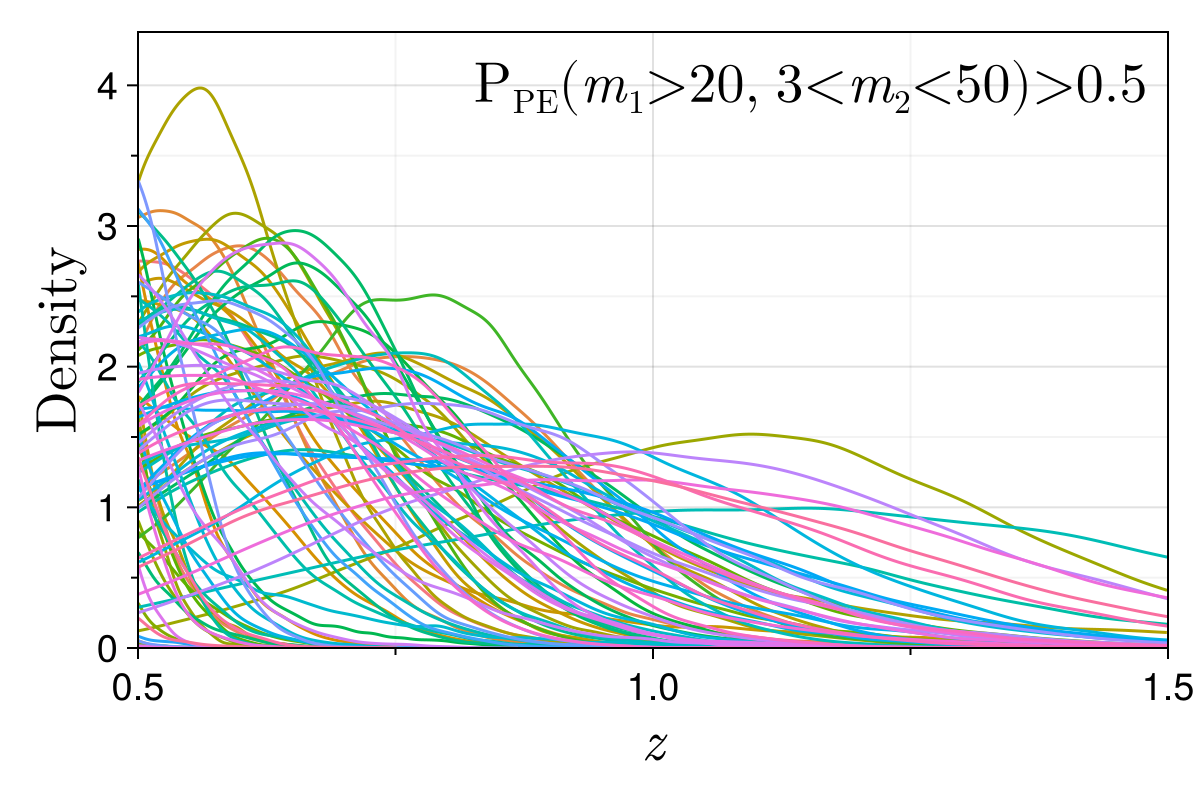

In [10]:
function frac_mass_bounds(df, m1_min, m2_min, m2_max)
    m1s = df[!, :mass_1_source]
    m2s = df[!, :mass_2_source]
    sum((m1s .> m1_min) .& (m2s .> m2_min) .& (m2s .< m2_max)) / length(m1s)
end

function z_kde_plot_zoom(df;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    zlow = 0.5,
    zhigh = 1.5,
    include_legend = false
)
    evt_groups = DataFrames.groupby(df, :gwname)

    evt_groups = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    cs = categorical_palette(length(evt_groups))

    f = Figure(size = (600, 400))

    a = Axis(f[1, 1];
        xlabel = L"z",
        ylabel = L"\mathrm{Density}",
        xlabelsize = xlabelsize,
        ylabelsize = ylabelsize,
        xticklabelsize = xticklabelsize,
        yticklabelsize = yticklabelsize,
        limits = (zlow, zhigh, nothing, nothing),
        xminorgridvisible = true,
        xminorticksvisible = true,
        yminorgridvisible = true,
        yminorticksvisible = true
    )

    cut_label = L"\mathrm{P}_{\mathrm{PE}}(m_1 > 20,\; 3 < m_2 < 50) > 0.5"

    ymax = 0.0

    @progress for (i, evt) in enumerate(evt_groups)
        c = cs[i]

        z = evt[!, :redshift]
        z = z[isfinite.(z)]

        if length(z) < 2
            continue
        end

        kde_result = kde(z)

        x = kde_result.x
        y = kde_result.density

        mask = (x .>= zlow) .& (x .<= zhigh)

        if !any(mask)
            continue
        end

        lines!(a, x[mask], y[mask]; color = c, linewidth = 1.5)

        ymax = max(ymax, maximum(y[mask]))
    end

    if ymax > 0
        ylims!(a, 0.0, 1.10 * ymax)
    end

    text!(
        a,
        0.98, 0.96;
        text = cut_label,
        align = (:right, :top),
        fontsize = 28,
        color = :black,
        space = :relative
    )

    if include_legend
        Legend(f[2, 1],
            [LineElement(color = cs[i], linestyle = nothing) for i in 1:length(evt_groups)],
            [evt[1, :gwname] for evt in evt_groups],
            nbanks = 3
        )
    end

    return f
end

f_z = z_kde_plot_zoom(pe; p_cut = 0.5, m2_max = 50.0)

f_z

In [19]:
# ============================================================
# Broken-power-law fit to PE redshift samples
# 100 PE samples per event
# ============================================================

using Turing
using StatsFuns
using StatsBase
using Random
using DataFrames

# ------------------------------------------------------------
# PE prior approximation
# pi_PE(z) ∝ z^2 / (1 + z)
# ------------------------------------------------------------
function log_pe_prior_z(z)
    if !(isfinite(z)) || z <= 0
        return -Inf
    end
    return 2.0 * log(z) - log1p(z)
end

# ------------------------------------------------------------
# Broken power-law redshift evolution
# ------------------------------------------------------------
function log_R_broken_powerlaw_z(z, λ_low, λ_high, z0)
    if !(isfinite(z)) || z <= 0 || z0 <= 0
        return -Inf
    end

    if z <= z0
        return λ_low * log1p(z)
    else
        return (λ_low - λ_high) * log1p(z0) + λ_high * log1p(z)
    end
end

# ------------------------------------------------------------
# Prepare event-wise PE redshift samples
# ------------------------------------------------------------
function prepare_z_pe_samples(df;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    nsamp_per_event = 100,
    rng = Random.default_rng()
)
    evt_groups = DataFrames.groupby(df, :gwname)

    selected = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    z_samples = Vector{Vector{Float64}}()
    event_names = String[]

    for evt in selected
        z = Vector{Float64}(evt[!, :redshift])
        z = z[isfinite.(z) .& (z .> 0)]

        if length(z) < 5
            continue
        end

        if length(z) > nsamp_per_event
            z = sample(rng, z, nsamp_per_event; replace = false)
        end

        push!(z_samples, z)
        push!(event_names, string(evt[1, :gwname]))
    end

    return z_samples, event_names
end

# ------------------------------------------------------------
# Load PE samples: 100 per event
# ------------------------------------------------------------
z_samples, event_names = prepare_z_pe_samples(
    pe;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    nsamp_per_event = 100
)

println("Number of selected events = ", length(z_samples))
println("PE samples per event ≈ ", median(length.(z_samples)))

# ------------------------------------------------------------
# Precompute PE prior terms
# ------------------------------------------------------------
log_pe_priors = [log_pe_prior_z.(z) for z in z_samples]

# ------------------------------------------------------------
# Turing model
# ------------------------------------------------------------
@model function broken_powerlaw_redshift_model(z_samples, log_pe_priors)
    λ_low  ~ Uniform(-10.0, 10.0)
    λ_high ~ Uniform(-10.0, 10.0)
    z0     ~ Uniform(0.05, 1.5)

    for i in eachindex(z_samples)
        z = z_samples[i]
        logπ = log_pe_priors[i]

        logw = [
            log_R_broken_powerlaw_z(z[j], λ_low, λ_high, z0) - logπ[j]
            for j in eachindex(z)
        ]

        Turing.@addlogprob! logsumexp(logw) - log(length(z))
    end
end

model_z = broken_powerlaw_redshift_model(z_samples, log_pe_priors)

# ------------------------------------------------------------
# Sampling
# ------------------------------------------------------------
chain_z = sample(
    model_z,
    Turing.NUTS(0.8),
    MCMCThreads(),
    400,
    4;
    discard_initial = 400
)

chain_z

Number of selected events = 115
PE samples per event ≈ 100.0


┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC /mnt/home/sroy1/.julia/packages/AbstractMCMC/FSyVk/src/sample.jl:382
Sampling (1 threads)   0%|                              |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference /mnt/home/sroy1/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
┌ Info: Found initial step size
│   ϵ = 0.043750000000000004
└ @ Turing.Inference /mnt/home/sroy1/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
Sampling (1 threads)  25%|███████▌                      |  ETA: 0:00:49
Sampling (1 threads)  50%|███████████████               |  ETA: 0:00:30
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference /mnt/home/sroy1/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
┌ Info: Found initial step size
│   ϵ = 0.4
└ @ Turing.Inference /mnt/home/sroy1/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
Sampling (1 threads)  75%|██████████████████████▌       |  ETA: 0:00:15
Sampling (

Chains MCMC chain (400×15×4 Array{Float64, 3}):

Iterations        = 401:1:800
Number of chains  = 4
Samples per chain = 400
Wall duration     = 56.16 seconds
Compute duration  = 56.06 seconds
parameters        = λ_low, λ_high, z0
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse   ess_bulk   ess_tail      rhat   e ⋯
      Symbol   Float64   Float64   Float64    Float64    Float64   Float64     ⋯

       λ_low    9.9802    0.0196    0.0006   562.6679   395.8533    1.0052     ⋯
      λ_high    6.3843    4.5360    0.1529   721.2048   440.8284    1.0092     ⋯
          z0    1.2728    0.2483    0.0113   623.5927   424.3012    1.0045     ⋯
                                                                1 column omitted

Quantiles
  parameters      2.5%     25.0%     50.0%     

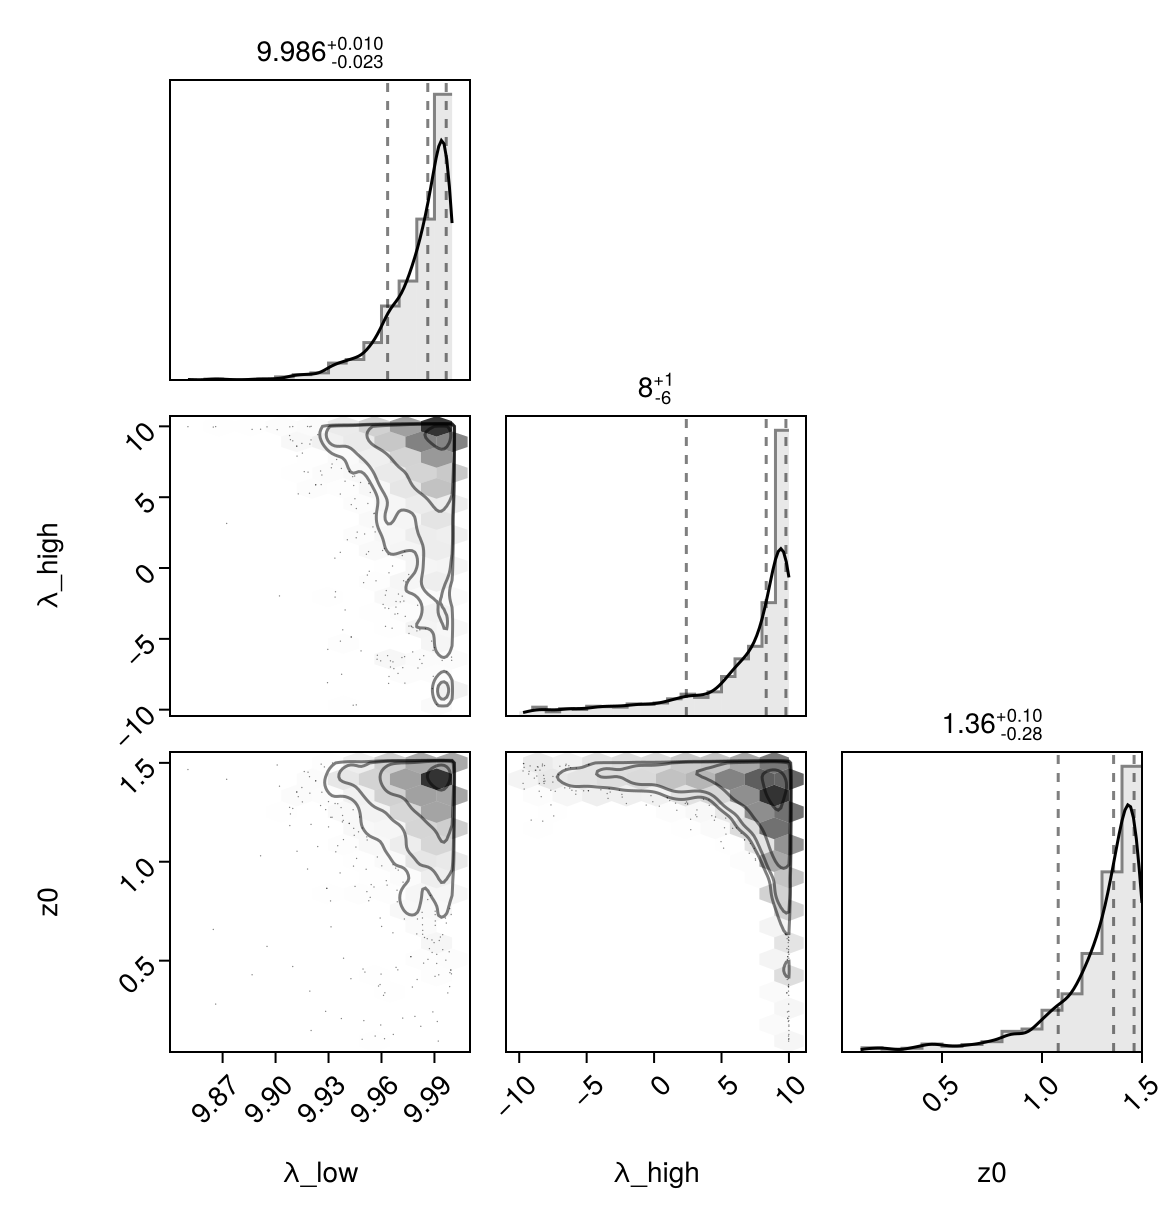

CairoMakie.Screen{IMAGE}


In [20]:
using DataFrames
using PairPlots
using CairoMakie

λ_low_samples  = vec(Array(chain_z[:, :λ_low, :]))
λ_high_samples = vec(Array(chain_z[:, :λ_high, :]))
z0_samples     = vec(Array(chain_z[:, :z0, :]))

df_z = DataFrame(
    λ_low = λ_low_samples,
    λ_high = λ_high_samples,
    z0 = z0_samples
)

fig_corner_z = PairPlots.pairplot(df_z)

display(fig_corner_z)

In [21]:
# ============================================================
# Population-model-free support beyond z > 0.7
# ============================================================

using DataFrames
using Statistics

function event_raw_highz_fraction(z; zcut = 0.7)
    z = z[isfinite.(z)]
    return mean(z .> zcut)
end

function raw_highz_support(df;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    zcut = 0.7
)
    evt_groups = DataFrames.groupby(df, :gwname)

    selected = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    event_names = String[]
    p_highz = Float64[]
    nsamp = Int[]

    for evt in selected
        z = Vector{Float64}(evt[!, :redshift])
        z = z[isfinite.(z)]

        if isempty(z)
            continue
        end

        push!(event_names, string(evt[1, :gwname]))
        push!(p_highz, event_raw_highz_fraction(z; zcut = zcut))
        push!(nsamp, length(z))
    end

    df_highz_raw = DataFrame(
        event = event_names,
        p_highz = p_highz,
        nsamp = nsamp
    )

    sort!(df_highz_raw, :p_highz, rev = true)

    N_events = nrow(df_highz_raw)
    N_eff_highz = sum(df_highz_raw.p_highz)
    f_eff_highz = N_eff_highz / N_events

    return df_highz_raw, N_eff_highz, f_eff_highz
end

df_highz_raw, N_eff_highz, f_eff_highz = raw_highz_support(
    pe;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    zcut = 0.7
)

println("Number of selected events = ", nrow(df_highz_raw))
println("Effective number of events with z > 0.7 support = ", N_eff_highz)
println("Effective fraction of support above z > 0.7 = ", f_eff_highz)

df_highz_raw

Number of selected events = 115
Effective number of events with z > 0.7 support = 25.218979195336765
Effective fraction of support above z > 0.7 = 0.21929547126379795


Row,event,p_highz,nsamp
,String,Float64,Int64
1,GW190805_211137,0.928516,63581
2,GW230704_212616,0.873888,21592
3,GW231005_021030,0.873608,14273
4,GW231119_075248,0.826055,36316
5,GW240107_013215,0.756457,32676
6,GW230806_204041,0.736612,40074
7,GW231230_170116,0.732114,30009
8,GW191230_180458,0.644199,36824
9,GW230630_125806,0.630235,44769


In [22]:
# ============================================================
# Compare PE support above zcut with pdet support
# ============================================================

using DataFrames
using Statistics
using DelimitedFiles
using Trapz

function event_raw_highz_fraction(z; zcut = 1.0)
    z = z[isfinite.(z)]
    return mean(z .> zcut)
end

function raw_highz_support(df;
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5,
    zcut = 1.0
)
    evt_groups = DataFrames.groupby(df, :gwname)

    selected = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    event_names = String[]
    p_highz = Float64[]

    for evt in selected
        z = Vector{Float64}(evt[!, :redshift])
        z = z[isfinite.(z)]

        if isempty(z)
            continue
        end

        push!(event_names, string(evt[1, :gwname]))
        push!(p_highz, event_raw_highz_fraction(z; zcut = zcut))
    end

    df_highz_raw = DataFrame(
        event = event_names,
        p_highz = p_highz
    )

    sort!(df_highz_raw, :p_highz, rev = true)

    N_events = nrow(df_highz_raw)
    N_eff_highz = sum(df_highz_raw.p_highz)
    f_eff_highz = N_eff_highz / N_events

    return df_highz_raw, N_eff_highz, f_eff_highz
end

function pdet_fraction_above_zcut(pdet_z_file; zcut = 1.0)
    pdet_z = readdlm(pdet_z_file)

    z = pdet_z[:, 1]
    pdet = pdet_z[:, 2]

    order = sortperm(z)
    z = z[order]
    pdet = pdet[order]

    mask_all = isfinite.(z) .& isfinite.(pdet) .& (pdet .>= 0)
    z = z[mask_all]
    pdet = pdet[mask_all]

    mask_high = z .> zcut

    if !any(mask_high)
        return 0.0
    end

    total = trapz(z, pdet)
    highz = trapz(z[mask_high], pdet[mask_high])

    return highz / total
end

# ------------------------------------------------------------
# Run comparison
# ------------------------------------------------------------
pdet_z_file = "../data/z_m1_35_q1_pdet.txt"

for zcut in [0.7, 1.0, 1.2]
    _, N_eff, f_eff = raw_highz_support(
        pe;
        m1_min = 20.0,
        m2_min = 3.0,
        m2_max = 50.0,
        p_cut = 0.5,
        zcut = zcut
    )

    f_pdet = pdet_fraction_above_zcut(
        pdet_z_file;
        zcut = zcut
    )

    println("z > ", zcut)
    println("  PE effective N above zcut      = ", N_eff)
    println("  PE support fraction above zcut = ", f_eff)
    println("  pdet integral fraction above   = ", f_pdet)
    println("  PE / pdet relative support     = ", f_eff / f_pdet)
end

z > 0.7
  PE effective N above zcut      = 25.218979195336765
  PE support fraction above zcut = 0.21929547126379795
  pdet integral fraction above   = 0.024256700279829364
  PE / pdet relative support     = 9.0406142935341
z > 1.0
  PE effective N above zcut      = 6.4078056560569685
  PE support fraction above zcut = 0.055720049183104074
  pdet integral fraction above   = 0.005589719087357193
  PE / pdet relative support     = 9.968309375176203
z > 1.2
  PE effective N above zcut      = 2.4325587647360707
  PE support fraction above zcut = 0.02115268491074844
  pdet integral fraction above   = 0.002645675913755468
  PE / pdet relative support     = 7.995191248017507


In [29]:
# ============================================================
# Stable bin-integrated redshift support diagnostic
# No KDE, no population fit
# ============================================================

using DataFrames
using Statistics
using DelimitedFiles
using Interpolations
using Trapz

# ------------------------------------------------------------
# Approximate PE redshift prior
# pi_PE(z) ∝ z^2 / (1+z)
# Replace with exact PE prior if known.
# ------------------------------------------------------------
function pe_prior_z(z)
    if !(isfinite(z)) || z <= 0
        return 0.0
    end
    return z^2 / (1 + z)
end

# ------------------------------------------------------------
# Event-level raw posterior probability in a redshift bin
# ------------------------------------------------------------
function event_bin_fraction(z; zlo = 0.0, zhi = 0.7)
    z = z[isfinite.(z)]
    if isempty(z)
        return NaN
    end
    return mean((z .>= zlo) .& (z .< zhi))
end

# ------------------------------------------------------------
# Collect event-level bin supports
# ------------------------------------------------------------
function redshift_bin_support(df;
    zbreak = 0.7,
    zmax = 1.5,
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5
)
    evt_groups = DataFrames.groupby(df, :gwname)

    selected = [
        evt for evt in evt_groups
        if frac_mass_bounds(evt, m1_min, m2_min, m2_max) >= p_cut
    ]

    event_names = String[]
    p_low = Float64[]
    p_high = Float64[]

    for evt in selected
        z = Vector{Float64}(evt[!, :redshift])
        z = z[isfinite.(z) .& (z .> 0)]

        if isempty(z)
            continue
        end

        push!(event_names, string(evt[1, :gwname]))
        push!(p_low, event_bin_fraction(z; zlo = 0.0, zhi = zbreak))
        push!(p_high, event_bin_fraction(z; zlo = zbreak, zhi = zmax))
    end

    df_bins = DataFrame(
        event = event_names,
        p_low = p_low,
        p_high = p_high
    )

    N_low = sum(df_bins.p_low)
    N_high = sum(df_bins.p_high)

    return df_bins, N_low, N_high
end

# ------------------------------------------------------------
# Integrated sensitivity in each redshift bin
# alpha_bin = ∫ pdet(z) pi_PE(z) dz
# ------------------------------------------------------------
function alpha_bin_integrals(pdet_z_file;
    zbreak = 0.7,
    zmax = 1.5,
    nz = 1000
)
    pdet_z = readdlm(pdet_z_file)

    zp = Vector{Float64}(pdet_z[:, 1])
    pp = Vector{Float64}(pdet_z[:, 2])

    order = sortperm(zp)
    zp = zp[order]
    pp = pp[order]

    itp = Interpolations.linear_interpolation(
        zp,
        pp;
        extrapolation_bc = Interpolations.Flat()
    )

    zgrid = collect(range(0.001, zmax, length = nz))

    pdet = itp.(zgrid)
    prior = pe_prior_z.(zgrid)

    integrand = pdet .* prior

    low_mask = zgrid .< zbreak
    high_mask = zgrid .>= zbreak

    alpha_low = trapz(zgrid[low_mask], integrand[low_mask])
    alpha_high = trapz(zgrid[high_mask], integrand[high_mask])

    z_eff_low = trapz(zgrid[low_mask], zgrid[low_mask] .* integrand[low_mask]) / alpha_low
    z_eff_high = trapz(zgrid[high_mask], zgrid[high_mask] .* integrand[high_mask]) / alpha_high

    return alpha_low, alpha_high, z_eff_low, z_eff_high
end

# ------------------------------------------------------------
# Run diagnostic
# ------------------------------------------------------------
zbreak = 0.7
zmax = 1.5
pdet_z_file = "../data/z_m1_35_q1_pdet.txt"

df_bins, N_low, N_high = redshift_bin_support(
    pe;
    zbreak = zbreak,
    zmax = zmax,
    m1_min = 20.0,
    m2_min = 3.0,
    m2_max = 50.0,
    p_cut = 0.5
)

alpha_low, alpha_high, z_eff_low, z_eff_high = alpha_bin_integrals(
    pdet_z_file;
    zbreak = zbreak,
    zmax = zmax
)

R_low_proxy = N_low / alpha_low
R_high_proxy = N_high / alpha_high

rate_ratio_high_low = R_high_proxy / R_low_proxy

lambda_eff = log(rate_ratio_high_low) / log((1 + z_eff_high) / (1 + z_eff_low))

println("Number of selected events = ", nrow(df_bins))
println("")
println("Raw PE effective support:")
println("  N_eff(z < ", zbreak, ")  = ", N_low)
println("  N_eff(z > ", zbreak, ")  = ", N_high)
println("  raw high-z fraction      = ", N_high / (N_low + N_high))
println("")
println("Sensitivity integrals:")
println("  alpha_low  = ", alpha_low)
println("  alpha_high = ", alpha_high)
println("  alpha_high / alpha_low = ", alpha_high / alpha_low)
println("")
println("Selection-corrected rate proxy:")
println("  R_low_proxy  ∝ ", R_low_proxy)
println("  R_high_proxy ∝ ", R_high_proxy)
println("  R_high / R_low = ", rate_ratio_high_low)
println("")
println("Effective slope between bins:")
println("  z_eff_low  = ", z_eff_low)
println("  z_eff_high = ", z_eff_high)
println("  lambda_eff = ", lambda_eff)

df_bins

Number of selected events = 115

Raw PE effective support:
  N_eff(z < 0.7)  = 89.78102080466323
  N_eff(z > 0.7)  = 24.71128028377119
  raw high-z fraction      = 0.2158335542988526

Sensitivity integrals:
  alpha_low  = 0.035359044037839356
  alpha_high = 0.005381313524390544
  alpha_high / alpha_low = 0.15219058294199783

Selection-corrected rate proxy:
  R_low_proxy  ∝ 2539.1246637942018
  R_high_proxy ∝ 4592.0536262695905
  R_high / R_low = 1.8085183810580245

Effective slope between bins:
  z_eff_low  = 0.4133537119511629
  z_eff_high = 0.9308100870138675
  lambda_eff = 1.899220645720381


Row,event,p_low,p_high
,String,Float64,Float64
1,GW150914_095045,1.0,0.0
2,GW151012_095443,1.0,0.0
3,GW170104_101158,1.0,0.0
4,GW170729_185629,0.922679,0.0773215
5,GW170809_082821,1.0,0.0
6,GW170814_103043,1.0,0.0
7,GW170818_022509,1.0,0.0
8,GW170823_131358,0.9999,0.0001
9,GW190408_181802,1.0,0.0
